In [66]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [67]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [68]:
config

{'data': {'raw': {'file1': '../data/raw/LeadScoring.csv',
   'file2': '../data/raw/Leads_Data_Dictionary.csv',
   'file3': '../data/raw/customer_segmentation_data.csv',
   'file4': '../data/raw/digital_marketing_campaign_dataset.csv'},
  'clean': {'file1': '../data/clean/leadscoring.csv'}}}

In [69]:
data = pd.read_csv(config['data']['clean']['file1'], quotechar='"', sep = ";")

In [5]:
data.drop(columns=['asymmetrique_activity_index', 'asymmetrique_profile_index',
       'asymmetrique_activity_score', 'asymmetrique_profile_score'], inplace=True)

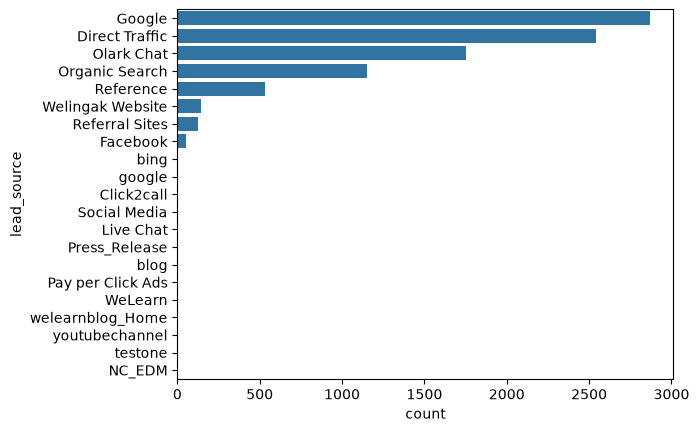

In [6]:
sns.countplot(data=data, y='lead_source', order= data['lead_source'].value_counts().index)
data['lead_source'] = data['lead_source'].replace({
    'google': 'Google'
})

In [7]:
top_res = data['lead_source'].value_counts().head(8).index

data['lead_source_other'] = data['lead_source']

data.loc[~data['lead_source_other'].isin(top_res), 'lead_source_other'] = 'other'

<Axes: xlabel='count', ylabel='lead_origin'>

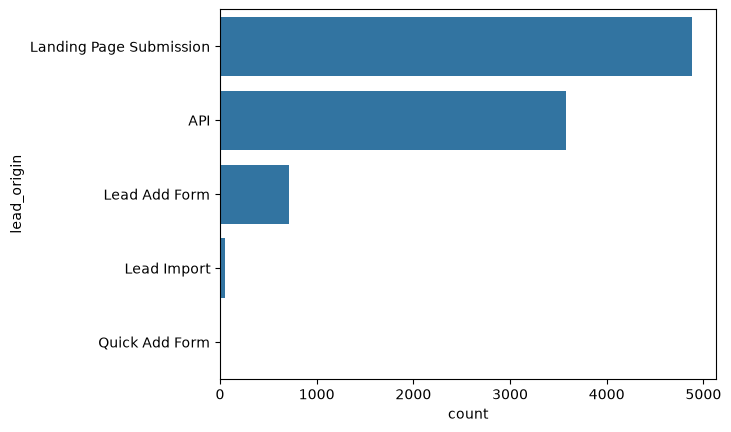

In [8]:
sns.countplot(data=data, y='lead_origin', order= data['lead_origin'].value_counts().index)

In [9]:
pivot = (
    data.groupby(['do_not_email', 'do_not_call'])['converted']
        .value_counts()
        .unstack(fill_value=0)
)
(100*pivot/pivot.sum()).round(1)

converted                    0     1
do_not_email do_not_call            
No           No           89.2  96.6
             Yes           0.0   0.1
Yes          No           10.8   3.3

In [10]:
data.columns

Index(['prospect_id', 'lead_number', 'lead_origin', 'lead_source',
       'do_not_email', 'do_not_call', 'converted', 'totalvisits',
       'time_on_website', 'page_views_per_visit', 'last_activity', 'country',
       'specialization', 'heard_about_x_ed', 'current_occupation',
       'most_imp_factor', 'search', 'magazine', 'newspaper_article',
       'x_education_forums', 'newspaper', 'digital_advertisement',
       'through_recommendations', 'get_updates', 'tags', 'lead_quality',
       'supply_chain_updates', 'get_updates_on_dm_content', 'lead_profile',
       'city', 'pay_by_cheque', 'interview_ebook', 'last_notable_activity',
       'lead_source_other'],
      dtype='str')

In [11]:
data.totalvisits.replace(np.nan,0)

0       0.0
1       5.0
2       2.0
3       1.0
4       2.0
       ... 
9235    8.0
9236    2.0
9237    2.0
9238    3.0
9239    6.0
Name: totalvisits, Length: 9240, dtype: float64

In [12]:
data[np.isnan(data.totalvisits)], data['totalvisits'].isnull().sum() 

(                               prospect_id  lead_number    lead_origin  \
 77    895d4905-f534-4f18-915b-8d239a72b5dc       659722  Lead Add Form   
 79    3a0ce10f-d2c1-4213-a2bc-4f97bcd29699       659710  Lead Add Form   
 81    277ad6a6-4565-4a18-a1ff-e46e03f22663       659705  Lead Add Form   
 88    68f496c2-0073-470f-9c3c-7fb48f060ce5       659631  Lead Add Form   
 120   144807db-2895-4002-b52e-3eda79c22395       659283  Lead Add Form   
 ...                                    ...          ...            ...   
 8097  82f3035c-0750-4f09-a0cc-4288abb88042       587973  Lead Add Form   
 8107  7e66be45-783c-4983-b4cd-c6594bbbeee8       587916  Lead Add Form   
 8434  f5be8a84-bfa2-46a6-816a-af81a45ea6b9       585438  Lead Add Form   
 9015  5857eeef-41cb-4523-a654-8709f6c8d8c6       581257  Lead Add Form   
 9087  915593f3-5db2-4a8f-8f7d-7936f6f00ca1       580713  Lead Add Form   
 
            lead_source do_not_email do_not_call  converted  totalvisits  \
 77    Welingak Websit

In [13]:
data['time_quartile'] = pd.qcut(data['time_on_website'], q=4, labels=['Q1','Q2','Q3','Q4'])
print(data[data['totalvisits'].isna()]['time_quartile'].value_counts())

time_quartile
Q4    74
Q3    39
Q2    23
Q1     1
Name: count, dtype: int64


In [14]:
data['totalvisits'] = data.groupby('time_quartile')['totalvisits'].transform(
    lambda x: x.fillna(x.median())
)

In [15]:
print(data[data['page_views_per_visit'].isna()]['time_quartile'].value_counts())

time_quartile
Q4    74
Q3    39
Q2    23
Q1     1
Name: count, dtype: int64


In [16]:
data['page_views_per_visit'] = data.groupby('time_quartile')['totalvisits'].transform(
    lambda x: x.fillna(x.median())
)

In [17]:
data.last_activity.isna().sum()/ len(data) * 100

np.float64(1.1147186147186148)

In [18]:
print(data[data['last_activity'].isna()]['converted'].mean())
print(data['converted'].mean())

0.7864077669902912
0.3853896103896104


In [19]:
data['no_last_activity'] = data['last_activity'].isna().astype(int)
data['last_activity'] = data['last_activity'].fillna('unknown')

In [20]:
data['last_activity'].unique()

<StringArray>
[     'Page Visited on Website',                 'Email Opened',
                  'Unreachable',            'Converted to Lead',
      'Olark Chat Conversation',                'Email Bounced',
           'Email Link Clicked',    'Form Submitted on Website',
                 'Unsubscribed',     'Had a Phone Conversation',
 'View in browser link Clicked',                      'unknown',
           'Approached upfront',                     'SMS Sent',
   'Visited Booth in Tradeshow',       'Resubscribed to emails',
               'Email Received',            'Email Marked Spam']
Length: 18, dtype: str

In [21]:
data.country.unique()
data['country'] = data['country'].fillna('unknown')

In [22]:
data.country.unique()

<StringArray>
[             'unknown',                'India',               'Russia',
               'Kuwait',                 'Oman', 'United Arab Emirates',
        'United States',            'Australia',       'United Kingdom',
              'Bahrain',                'Ghana',            'Singapore',
                'Qatar',         'Saudi Arabia',              'Belgium',
               'France',            'Sri Lanka',                'China',
               'Canada',          'Netherlands',               'Sweden',
              'Nigeria',            'Hong Kong',              'Germany',
  'Asia/Pacific Region',               'Uganda',                'Kenya',
                'Italy',         'South Africa',             'Tanzania',
             'Malaysia',              'Liberia',          'Switzerland',
              'Denmark',          'Philippines',           'Bangladesh',
              'Vietnam',            'Indonesia']
Length: 38, dtype: str

In [23]:
data.country.value_counts().sort_index()

country
Asia/Pacific Region        2
Australia                 13
Bahrain                    7
Bangladesh                 2
Belgium                    2
Canada                     4
China                      2
Denmark                    1
France                     6
Germany                    4
Ghana                      2
Hong Kong                  7
India                   6492
Indonesia                  1
Italy                      2
Kenya                      1
Kuwait                     4
Liberia                    1
Malaysia                   1
Netherlands                2
Nigeria                    4
Oman                       6
Philippines                2
Qatar                     10
Russia                     1
Saudi Arabia              21
Singapore                 24
South Africa               4
Sri Lanka                  1
Sweden                     3
Switzerland                1
Tanzania                   1
Uganda                     2
United Arab Emirates      53
United

In [24]:
def country_group(x):
    if x == "India":
        return "India"
    elif x == "unknown":
        return "Unknown"
    else:
        return "Other"

data["country_group"] = data["country"].apply(country_group)

In [25]:
data.specialization.unique()

<StringArray>
[                           'Select',           'Business Administration',
             'Media and Advertising',                                 nan,
           'Supply Chain Management',            'IT Projects Management',
                'Finance Management',                'Travel and Tourism',
         'Human Resource Management',              'Marketing Management',
 'Banking, Investment And Insurance',            'International Business',
                        'E-COMMERCE',             'Operations Management',
                 'Retail Management',               'Services Excellence',
            'Hospitality Management',            'Rural and Agribusiness',
             'Healthcare Management',                        'E-Business']
Length: 20, dtype: str

In [26]:
data.specialization = data.specialization.fillna('unknown')
data.specialization = data.specialization.replace('Select','unknown')

In [27]:
data.heard_about_x_ed.value_counts()

heard_about_x_ed
Select                   5043
Online Search             808
Word Of Mouth             348
Student of SomeSchool     310
Other                     186
Multiple Sources          152
Advertisements             70
Social Media               67
Email                      26
SMS                        23
Name: count, dtype: int64

In [28]:
data.heard_about_x_ed = data.heard_about_x_ed.fillna('other/unknown')
data.heard_about_x_ed = data.heard_about_x_ed.replace('Select','other/unknown')
data.heard_about_x_ed = data.heard_about_x_ed.replace('Other','other/unknown')
data.heard_about_x_ed.value_counts()

heard_about_x_ed
other/unknown            7436
Online Search             808
Word Of Mouth             348
Student of SomeSchool     310
Multiple Sources          152
Advertisements             70
Social Media               67
Email                      26
SMS                        23
Name: count, dtype: int64

In [29]:
data.current_occupation.value_counts()

current_occupation
Unemployed              5600
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [30]:
data.current_occupation = data.current_occupation.replace('Businessman','Working Professional')

In [31]:
data.most_imp_factor.value_counts()
data = data.drop(columns=['most_imp_factor'])

In [32]:
data.search.value_counts()
data = data.drop(columns='search')

In [33]:
data.magazine.value_counts()
data = data.drop(columns='magazine')

In [34]:
data.newspaper_article.value_counts()
data = data.drop(columns=['newspaper_article'])

In [35]:
data.x_education_forums.value_counts()
data = data.drop(columns=['x_education_forums'])

In [36]:
data.newspaper.value_counts()
data = data.drop(columns=['newspaper'])

In [37]:
data.digital_advertisement.value_counts()
data = data.drop(columns=['digital_advertisement'])

In [38]:
data.through_recommendations.value_counts()
data = data.drop(columns=['through_recommendations'])

In [39]:
data.get_updates.value_counts()
data = data.drop(columns='get_updates')

In [40]:
data.tags.value_counts()

tags
Will revert after reading the email                  2072
Ringing                                              1203
Interested in other courses                           513
Already a student                                     465
Closed by Horizzon                                    358
switched off                                          240
Busy                                                  186
Lost to EINS                                          175
Not doing further education                           145
Interested  in full time MBA                          117
Graduation in progress                                111
invalid number                                         83
Diploma holder (Not Eligible)                          63
wrong number given                                     47
opp hangup                                             33
number not provided                                    27
in touch with EINS                                     12
Lost to O

In [41]:
data.lead_quality.value_counts()
#looks ordinal

lead_quality
Might be             1560
Not Sure             1092
High in Relevance     637
Worst                 601
Low in Relevance      583
Name: count, dtype: int64

In [42]:
quality_map = {
    "Worst": 1,
    "Low in Relevance": 2,
    "Not Sure": 3,
    "Might be": 3.5,
    "High in Relevance": 5
}
data["lead_quality_score"] = data["lead_quality"].map(quality_map)

In [43]:
data.supply_chain_updates.value_counts()
data = data.drop(columns=['supply_chain_updates'])

In [44]:
data.get_updates_on_dm_content.value_counts()
data = data.drop(columns=['get_updates_on_dm_content'])

In [45]:
data.lead_profile.value_counts()

lead_profile
Select                         4146
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [46]:
data["lead_profile"] = data["lead_profile"].fillna("Unknown")

def profile_group(x):
    if x in ["Select", "Unknown"]:
        return "Unknown"
    elif "Student" in x:
        return "Student"
    else:
        return "Lead"

data["lead_profile_group"] = data["lead_profile"].apply(profile_group)

In [47]:
data.lead_profile_group.value_counts()

lead_profile_group
Unknown    6855
Lead       2100
Student     285
Name: count, dtype: int64

In [48]:
data.city.value_counts()

city
Mumbai                         3222
Select                         2249
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

In [49]:
data.groupby("city")["converted"].agg(["count","mean"])

,count,mean
city,,
Mumbai,3222,0.406269
Other Cities,686,0.402332
Other Cities of Maharashtra,457,0.439825
Other Metro Cities,380,0.407895
Select,2249,0.490440
Thane & Outskirts,752,0.449468
Tier II Cities,74,0.337838


In [50]:
def city_group(x):
    if x == "Tier II Cities":
        return "Tier2"
    elif x == "Select":
        return "Unknown"
    elif x in ["Mumbai", "Thane & Outskirts", "Other Cities of Maharashtra"]:
        return "Maharashtra_Urban"
    else:
        return "Metro_or_Other"

data["city_group"] = data["city"].apply(city_group)

In [51]:
data.pay_by_cheque.value_counts()
data = data.drop(columns=['pay_by_cheque'])

In [52]:
data.interview_ebook.value_counts()

interview_ebook
No     6352
Yes    2888
Name: count, dtype: int64

In [53]:
data.last_notable_activity.value_counts()

last_notable_activity
Modified                        3407
Email Opened                    2827
SMS Sent                        2172
Page Visited on Website          318
Olark Chat Conversation          183
Email Link Clicked               173
Email Bounced                     60
Unsubscribed                      47
Unreachable                       32
Had a Phone Conversation          14
Email Marked Spam                  2
Approached upfront                 1
Resubscribed to emails             1
View in browser link Clicked       1
Form Submitted on Website          1
Email Received                     1
Name: count, dtype: int64

In [56]:
activity_map = {
    'Email Opened': 'passive_engagement',
    'Email Link Clicked': 'active_engagement',
    'Email Marked Spam': 'negative_signal',
    'Email Bounced': 'negative_signal',
    'Unsubscribed': 'negative_signal',
    'Unreachable': 'negative_signal',
    'SMS Sent': 'outreach',
    'Modified': 'outreach',
    'Email Received': 'outreach',
    'Page Visited on Website': 'active_engagement',
    'Form Submitted on Website': 'active_engagement',
    'View in browser link Clicked': 'active_engagement',
    'Olark Chat Conversation': 'high_intent',
    'Had a Phone Conversation': 'high_intent',
    'Approached upfront': 'high_intent',
    'Resubscribed to emails': 'high_intent'
}

data['activity_intent'] = data['last_notable_activity'].map(activity_map)

In [64]:
print(data.groupby('last_notable_activity')['converted'].mean().sort_values(ascending=False))

last_notable_activity
Approached upfront              1.000000
Email Marked Spam               1.000000
Email Received                  1.000000
Resubscribed to emails          1.000000
Had a Phone Conversation        0.928571
SMS Sent                        0.694291
Unreachable                     0.687500
Email Opened                    0.369296
Unsubscribed                    0.297872
Page Visited on Website         0.292453
Email Link Clicked              0.260116
Modified                        0.229821
Email Bounced                   0.150000
Olark Chat Conversation         0.136612
Form Submitted on Website       0.000000
View in browser link Clicked    0.000000
Name: converted, dtype: float64


In [57]:
data.groupby('activity_intent')['converted'].mean().sort_values(ascending=False)

activity_intent
outreach              0.410753
passive_engagement    0.369296
negative_signal       0.333333
active_engagement     0.279919
high_intent           0.201005
Name: converted, dtype: float64

In [ ]:
data.columns

In [60]:
data.columns

Index(['prospect_id', 'lead_number', 'lead_origin', 'lead_source',
       'do_not_email', 'do_not_call', 'converted', 'totalvisits',
       'time_on_website', 'page_views_per_visit', 'last_activity', 'country',
       'specialization', 'heard_about_x_ed', 'current_occupation', 'tags',
       'lead_quality', 'lead_profile', 'city', 'interview_ebook',
       'last_notable_activity', 'lead_source_other', 'time_quartile',
       'no_last_activity', 'country_group', 'lead_quality_score',
       'lead_profile_group', 'city_group', 'activity_intent'],
      dtype='str')